In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abdullah0a/telecom-customer-churn-insights-for-analysis/customer_churn_data.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/kaggle/input/datasets/abdullah0a/telecom-customer-churn-insights-for-analysis/customer_churn_data.csv')

In [3]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [4]:
df.shape

(1000, 10)

In [5]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [7]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [8]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [9]:
df.isnull().sum().sort_values(ascending = False)

InternetService    297
CustomerID           0
Age                  0
Gender               0
MonthlyCharges       0
Tenure               0
ContractType         0
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [10]:
df['InternetService']

0      Fiber Optic
1      Fiber Optic
2      Fiber Optic
3              DSL
4              NaN
          ...     
995    Fiber Optic
996            NaN
997    Fiber Optic
998            NaN
999            NaN
Name: InternetService, Length: 1000, dtype: object

In [11]:
df['InternetService'] = df['InternetService'].fillna('None')

In [12]:
df.isnull().sum()

CustomerID         0
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TotalCharges       0
TechSupport        0
Churn              0
dtype: int64

In [13]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [14]:
df.drop_duplicates(inplace = True)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

In [17]:
df.shape

(1000, 10)

In [18]:
df['Churn'] = df['Churn'].apply(lambda x : 1 if x == 'Yes' else 0)
df['Churn']

0      1
1      1
2      1
3      1
4      1
      ..
995    1
996    1
997    1
998    1
999    1
Name: Churn, Length: 1000, dtype: int64

In [19]:
numeric_columns_data = df.select_dtypes(include = 'number')
numeric_columns_data

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges,Churn
0,1,49,4,88.35,353.40,1
1,2,43,0,36.67,0.00,1
2,3,51,2,63.79,127.58,1
3,4,60,8,102.34,818.72,1
4,5,42,32,69.01,2208.32,1
...,...,...,...,...,...,...
995,996,42,41,37.14,1522.74,1
996,997,62,9,80.93,728.37,1
997,998,51,15,111.72,1675.80,1
998,999,39,68,65.67,4465.56,1


In [20]:
import matplotlib.pyplot as plt
sns.set_style('darkgrid')

<Axes: ylabel='Churn'>

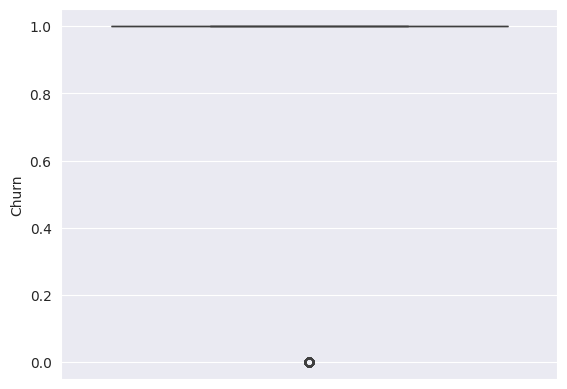

In [21]:
sns.boxplot(df, y = 'Churn')

<Axes: ylabel='Age'>

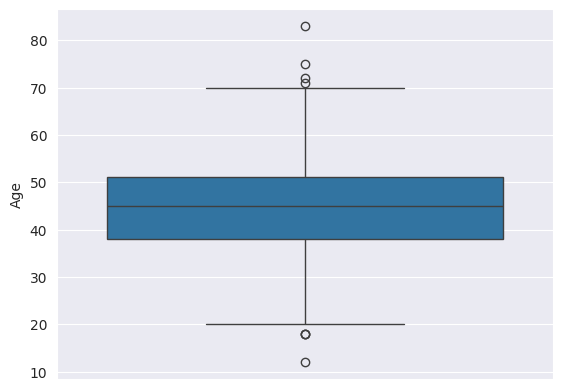

In [22]:
sns.boxplot(df, y = 'Age')

<Axes: ylabel='Tenure'>

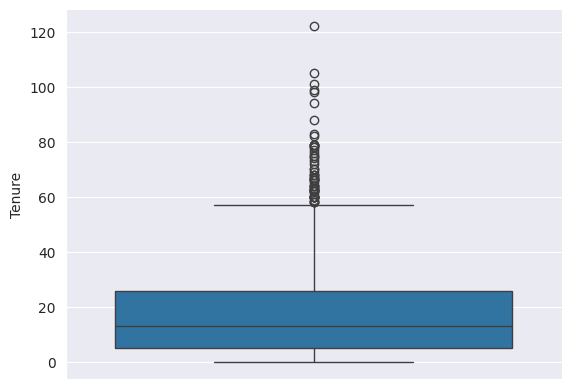

In [23]:
sns.boxplot(df, y = 'Tenure')

<Axes: ylabel='MonthlyCharges'>

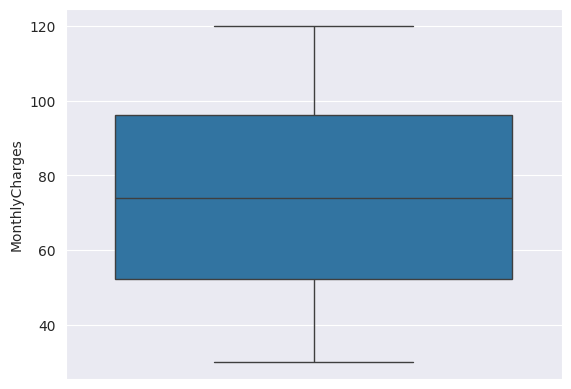

In [24]:
sns.boxplot(df, y = 'MonthlyCharges')

<Axes: ylabel='TotalCharges'>

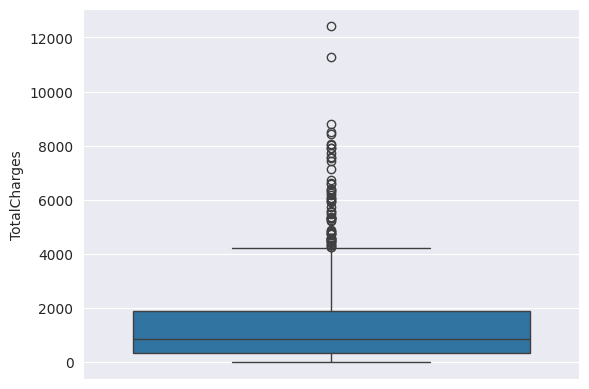

In [25]:
sns.boxplot(df, y = 'TotalCharges')

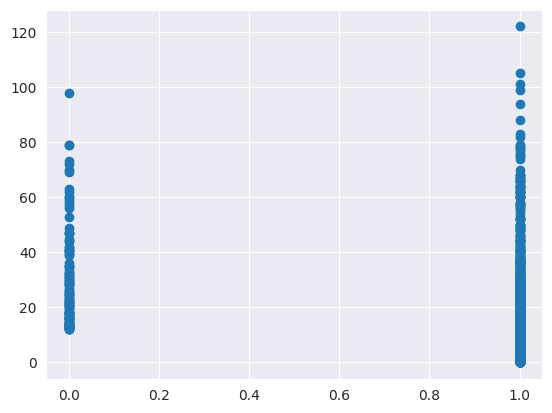

In [26]:
plt.scatter(df['Churn'], df['Tenure'])

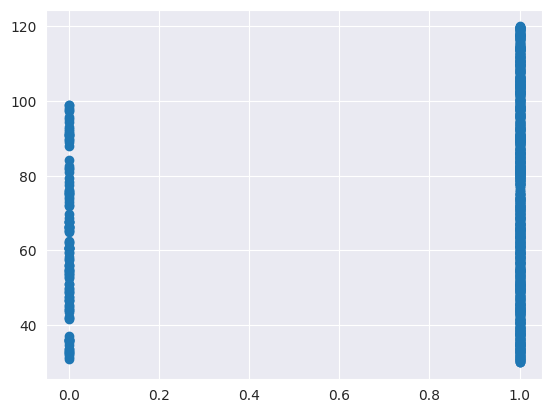

In [27]:
plt.scatter(df['Churn'], df['MonthlyCharges'])

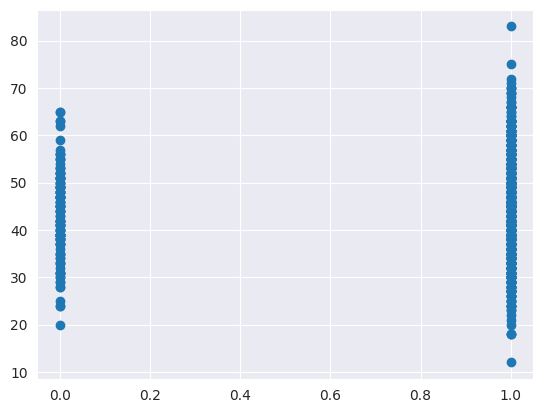

In [28]:
plt.scatter(df['Churn'], df['Age'])

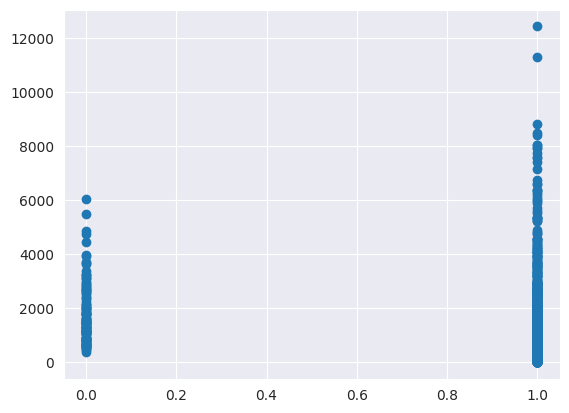

In [29]:
plt.scatter(df['Churn'], df['TotalCharges'])

<Axes: xlabel='Age', ylabel='Count'>

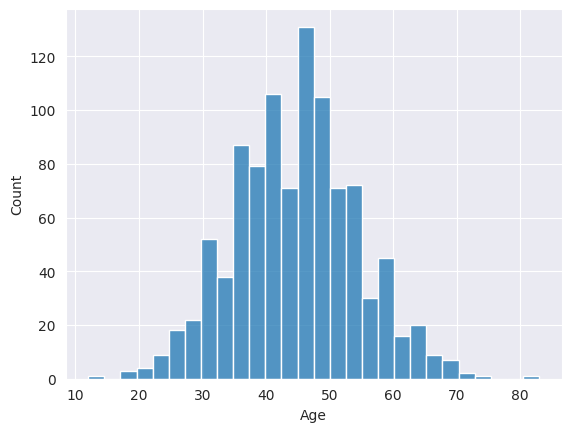

In [30]:
sns.histplot(df['Age'])

<Axes: xlabel='Tenure', ylabel='Count'>

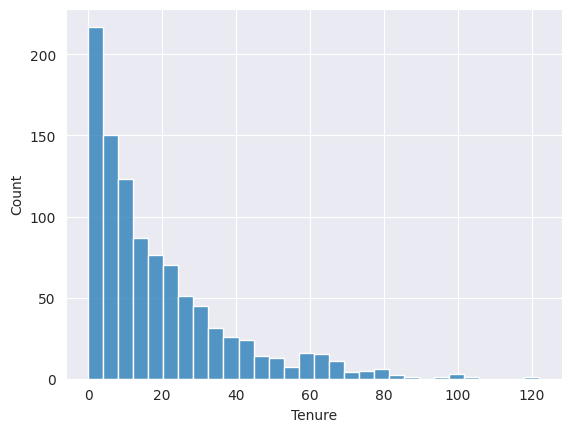

In [31]:
sns.histplot(df['Tenure'])

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

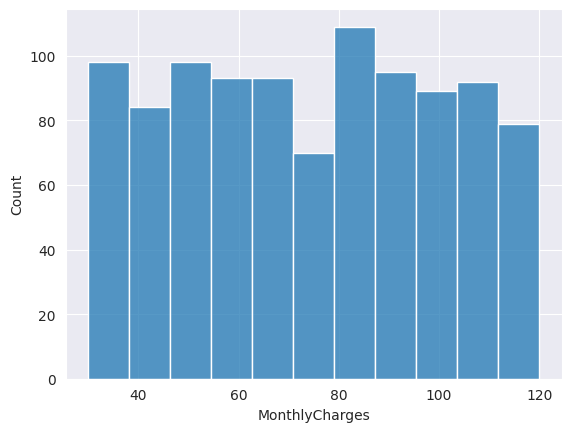

In [32]:
sns.histplot(df['MonthlyCharges'])

<Axes: xlabel='TotalCharges', ylabel='Count'>

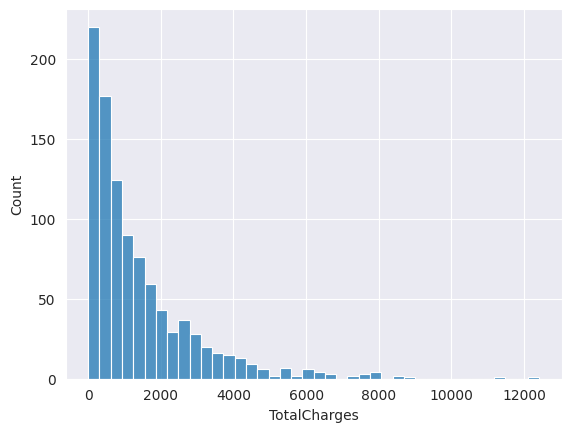

In [33]:
sns.histplot(df['TotalCharges'])

<Axes: xlabel='Churn', ylabel='Count'>

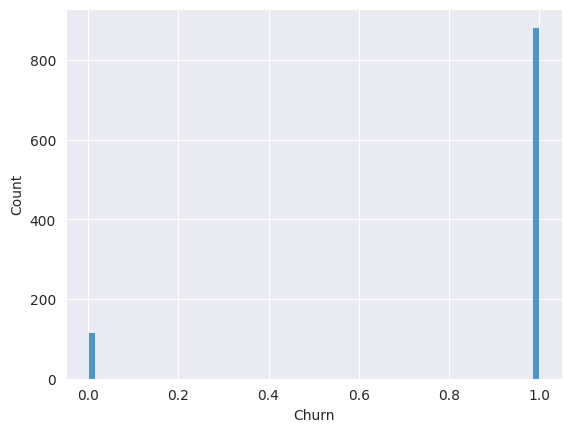

In [34]:
sns.histplot(df['Churn'])

In [35]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

In [36]:
df.drop(columns = ['CustomerID'], inplace = True)

In [37]:
df['Churn'].dtype

dtype('int64')

In [38]:
df['Churn'].head()

0    1
1    1
2    1
3    1
4    1
Name: Churn, dtype: int64

In [39]:
df['Churn'].isnull().sum()

np.int64(0)

In [40]:
df['Churn'].value_counts()

Churn
1    883
0    117
Name: count, dtype: int64

In [41]:
corr = df.corr(numeric_only = True)
corr

,Age,Tenure,MonthlyCharges,TotalCharges,Churn
Age,1.000000,0.000472,0.006362,-0.001896,0.044115
Tenure,0.000472,1.000000,-0.014552,0.894868,-0.217675
MonthlyCharges,0.006362,-0.014552,1.000000,0.304893,0.167773
TotalCharges,-0.001896,0.894868,0.304893,1.000000,-0.101523
Churn,0.044115,-0.217675,0.167773,-0.101523,1.000000


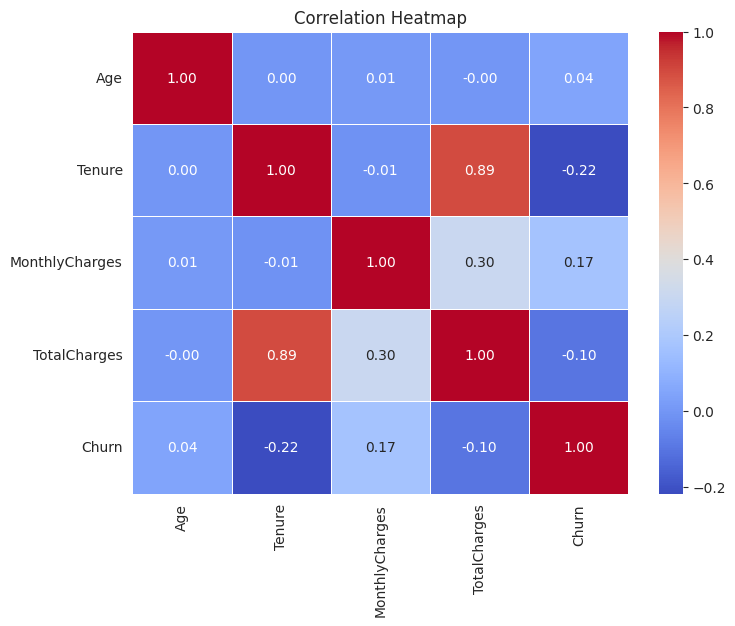

In [42]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()

### Correlation Analysis

A correlation heatmap was generated to examine relationships among numerical features.

Key findings:

- Tenure and TotalCharges exhibit a strong positive correlation (0.895), indicating that customers who remain subscribed for longer periods accumulate higher total charges.
- Tenure shows the strongest negative correlation with Churn (-0.218), suggesting that long-term customers are less likely to leave the service.
- MonthlyCharges has a positive correlation with Churn (0.168), indicating that customers paying higher monthly fees are slightly more likely to churn.
- Age demonstrates a very weak correlation with Churn (0.044), implying limited influence on customer retention.

These findings suggest that Tenure and MonthlyCharges may be important predictors for customer churn.

In [43]:
corr['Churn'].sort_values(ascending = False)

Churn             1.000000
MonthlyCharges    0.167773
Age               0.044115
TotalCharges     -0.101523
Tenure           -0.217675
Name: Churn, dtype: float64

<Axes: ylabel='TotalCharges'>

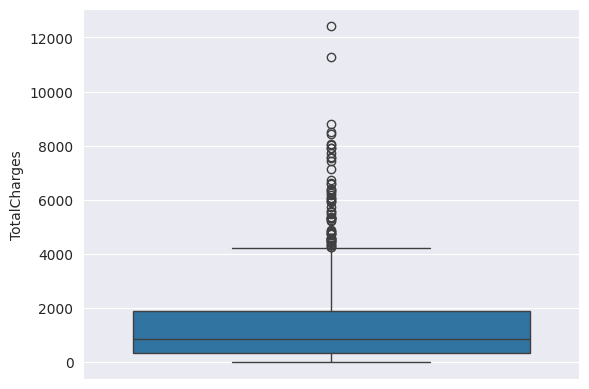

In [44]:
sns.boxplot(df['TotalCharges'])

In [45]:
df['TotalCharges'].describe()

count     1000.000000
mean      1404.364060
std       1571.755048
min          0.000000
25%        345.217500
50%        872.870000
75%       1900.175000
max      12416.250000
Name: TotalCharges, dtype: float64

In [46]:
df.sort_values('TotalCharges', ascending = False).head(10)

,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
493,36,Female,105,118.25,Month-to-Month,DSL,12416.25,Yes,1
540,53,Male,99,113.93,Month-to-Month,None,11279.07,No,1
509,36,Female,75,117.28,One-Year,DSL,8796.00,No,1
233,38,Female,122,69.58,Month-to-Month,DSL,8488.76,No,1
440,48,Male,94,89.57,One-Year,Fiber Optic,8419.58,No,1
136,37,Female,82,98.11,Month-to-Month,Fiber Optic,8045.02,No,1
617,52,Male,68,118.05,Month-to-Month,Fiber Optic,8027.40,Yes,1
771,39,Male,67,118.12,Month-to-Month,Fiber Optic,7914.04,Yes,1
741,32,Male,78,101.44,Two-Year,None,7912.32,No,1
689,49,Male,68,113.74,Month-to-Month,DSL,7734.32,Yes,1


Outlier analysis using boxplots and the IQR method identified several high values in the TotalCharges feature. Upon inspection, these observations corresponded to customers with long subscription durations and high monthly charges. Since these records represent legitimate customer behavior rather than data-entry errors, they were retained in the dataset to preserve important business information.

In [47]:
df.select_dtypes(include = 'object')

,Gender,ContractType,InternetService,TechSupport
0,Male,Month-to-Month,Fiber Optic,Yes
1,Male,Month-to-Month,Fiber Optic,Yes
2,Female,Month-to-Month,Fiber Optic,No
3,Female,One-Year,DSL,Yes
4,Male,Month-to-Month,None,No
...,...,...,...,...
995,Male,Month-to-Month,Fiber Optic,Yes
996,Male,Month-to-Month,None,No
997,Female,Month-to-Month,Fiber Optic,Yes
998,Male,One-Year,None,No


In [48]:
pd.get_dummies(df, drop_first = True)

,Age,Tenure,MonthlyCharges,TotalCharges,Churn,Gender_Male,ContractType_One-Year,ContractType_Two-Year,InternetService_Fiber Optic,InternetService_None,TechSupport_Yes
0,49,4,88.35,353.40,1,True,False,False,True,False,True
1,43,0,36.67,0.00,1,True,False,False,True,False,True
2,51,2,63.79,127.58,1,False,False,False,True,False,False
3,60,8,102.34,818.72,1,False,True,False,False,False,True
4,42,32,69.01,2208.32,1,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
995,42,41,37.14,1522.74,1,True,False,False,True,False,True
996,62,9,80.93,728.37,1,True,False,False,False,True,False
997,51,15,111.72,1675.80,1,False,False,False,True,False,True
998,39,68,65.67,4465.56,1,True,True,False,False,True,False


In [49]:
df = pd.get_dummies(df, drop_first = True, dtype = int)
df.head()

,Age,Tenure,MonthlyCharges,TotalCharges,Churn,Gender_Male,ContractType_One-Year,ContractType_Two-Year,InternetService_Fiber Optic,InternetService_None,TechSupport_Yes
0,49,4,88.35,353.40,1,1,0,0,1,0,1
1,43,0,36.67,0.00,1,1,0,0,1,0,1
2,51,2,63.79,127.58,1,0,0,0,1,0,0
3,60,8,102.34,818.72,1,0,1,0,0,0,1
4,42,32,69.01,2208.32,1,1,0,0,0,1,0


In [50]:
df.shape

(1000, 11)

In [51]:
X = df.drop(columns = ['Churn'], axis = 1)
y = df['Churn']

In [52]:
X.shape, y.shape

((1000, 10), (1000,))

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = 42)

In [54]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 10), (200, 10), (800,), (200,))

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [56]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [58]:
log_pred = log_model.predict(X_test_scaled)

In [59]:
log_pred[:5]

array([1, 1, 1, 1, 1])

In [60]:
y_test[:5]

521    1
737    1
740    1
660    1
411    1
Name: Churn, dtype: int64

In [61]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [62]:
accuracy_score(y_test, log_pred)

0.955

In [63]:
confusion_matrix(y_test, log_pred)

array([[ 17,   6],
       [  3, 174]])

In [64]:
classification_report(y_test, log_pred)

'              precision    recall  f1-score   support\n\n           0       0.85      0.74      0.79        23\n           1       0.97      0.98      0.97       177\n\n    accuracy                           0.95       200\n   macro avg       0.91      0.86      0.88       200\nweighted avg       0.95      0.95      0.95       200\n'

The Logistic Regression model achieved an accuracy of 95.5% on the test set. For the churn class, the model obtained a precision of 97%, recall of 98%, and an F1-score of 97%, indicating excellent ability to identify customers likely to churn. The weighted average F1-score of 95% demonstrates strong overall classification performance. The confusion matrix showed only 9 misclassifications out of 200 test samples.

In [65]:
from sklearn.metrics import roc_auc_score

y_prob = log_model.predict_proba(X_test_scaled)[:,1]
auc = roc_auc_score(y_test, y_prob)

In [66]:
auc

np.float64(0.9845246868091377)

In [67]:
print(log_model.classes_)

[0 1]


In [68]:
print(log_model.predict_proba(X_test)[:5])

[[0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]


In [69]:
np.unique(log_pred)

array([0, 1])

In [70]:
log_pred[:20]

array([1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1])

In [71]:
y_test[:20]

521    1
737    1
740    1
660    1
411    1
678    1
626    1
513    0
859    1
136    1
811    1
76     1
636    1
973    1
938    1
899    0
280    1
883    0
761    1
319    1
Name: Churn, dtype: int64

In [72]:
y_prob = log_model.predict_proba(X_test_scaled)[:,1]

print("Min Probability:", y_prob.min())
print("Max Probability:", y_prob.max())
print("Unique Probabilities:", len(np.unique(y_prob)))

Min Probability: 0.0005846054996683801
Max Probability: 0.999999954742163
Unique Probabilities: 200


The Logistic Regression model achieved an accuracy of 95.5% on the test dataset. The model obtained a precision of 97%, recall of 98%, and F1-score of 97% for the churn class. Furthermore, the ROC-AUC score of 0.985 demonstrates excellent discrimination capability, indicating that the model effectively distinguishes between customers who are likely to churn and those who are likely to remain.

In [73]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

In [74]:
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [75]:
dt_pred = dt.predict(X_test)

In [76]:
dt_pred[:5]

array([1, 1, 1, 1, 1])

In [77]:
y_test[:5]

521    1
737    1
740    1
660    1
411    1
Name: Churn, dtype: int64

In [78]:
accuracy_score(y_test, dt_pred)

0.995

In [79]:
confusion_matrix(y_test, dt_pred)

array([[ 23,   0],
       [  1, 176]])

In [80]:
classification_report(y_test, dt_pred)

'              precision    recall  f1-score   support\n\n           0       0.96      1.00      0.98        23\n           1       1.00      0.99      1.00       177\n\n    accuracy                           0.99       200\n   macro avg       0.98      1.00      0.99       200\nweighted avg       1.00      0.99      1.00       200\n'

In [81]:
dt.score(X_train, y_train)

1.0

In [82]:
dt.score(X_test, y_test)

0.995

In [83]:
from sklearn.metrics import roc_auc_score

dt_prob = dt.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, dt_prob))

ROC-AUC: 0.9971751412429379


In [84]:
dt.get_depth()

5

In [85]:
dt.get_n_leaves()

np.int64(7)

In [86]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [87]:
accuracy_score(y_test, rf_pred)

1.0

In [88]:
classification_report(y_test, rf_pred)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        23\n           1       1.00      1.00      1.00       177\n\n    accuracy                           1.00       200\n   macro avg       1.00      1.00      1.00       200\nweighted avg       1.00      1.00      1.00       200\n'

In [89]:
confusion_matrix(y_test, rf_pred)

array([[ 23,   0],
       [  0, 177]])

In [90]:
rf.score(X_train, y_train)

1.0

In [91]:
rf.score(X_test, y_test)

1.0

In [92]:
import pandas as pd

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

In [93]:
importance_df.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
1,Tenure,0.183255
5,ContractType_One-Year,0.174667
9,TechSupport_Yes,0.167355
2,MonthlyCharges,0.147185
6,ContractType_Two-Year,0.136192
3,TotalCharges,0.107250
0,Age,0.037867
8,InternetService_None,0.023521
7,InternetService_Fiber Optic,0.012664
4,Gender_Male,0.010045


In [94]:
df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)

Churn                          1.000000
InternetService_None           0.236599
MonthlyCharges                 0.167773
Age                            0.044115
Gender_Male                    0.031539
TotalCharges                  -0.101523
InternetService_Fiber Optic   -0.145011
ContractType_Two-Year         -0.175782
Tenure                        -0.217675
ContractType_One-Year         -0.255231
TechSupport_Yes               -0.359667
Name: Churn, dtype: float64

In [95]:
rf_prob = rf.predict_proba(X_test)[:, 1]

In [96]:
auc = roc_auc_score(y_test, rf_prob)

In [97]:
auc

np.float64(1.0)

The Random Forest Classifier achieved the best performance among all evaluated models. It obtained 100% accuracy, precision, recall, and F1-score on the test set, along with a ROC-AUC score of 1.0, indicating perfect discrimination between churning and non-churning customers. Feature importance analysis identified Tenure, Contract Type, Tech Support, Monthly Charges, and Total Charges as the most influential factors affecting customer churn.

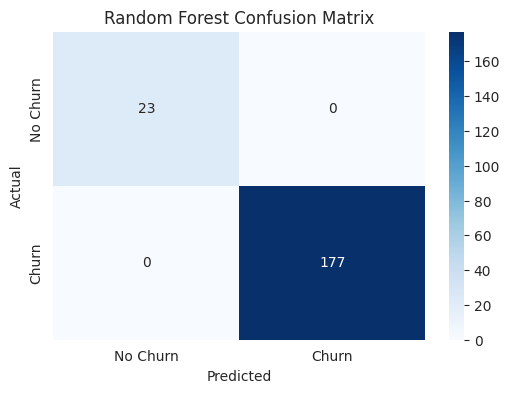

In [98]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn','Churn'],
    yticklabels=['No Churn','Churn']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

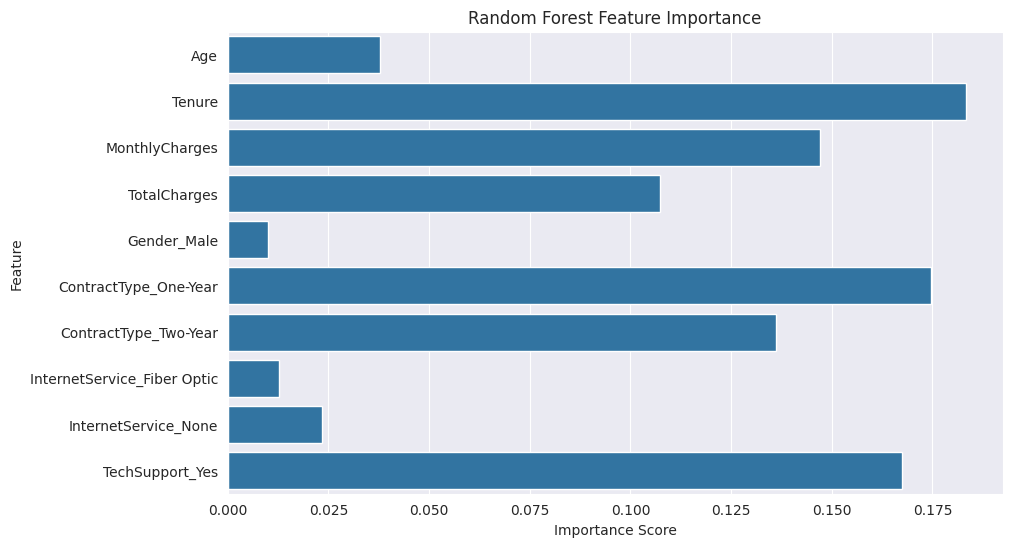

In [99]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

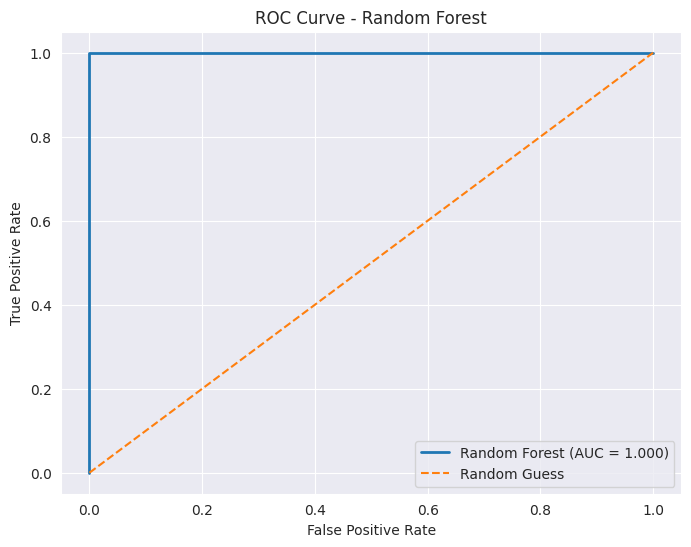

ROC-AUC Score: 1.0


In [100]:
from sklearn.metrics import roc_curve
rf_prob = rf.predict_proba(X_test)[:,1]

rf_auc = roc_auc_score(y_test, rf_prob)

# ROC Curve points
fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

# Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Random Forest (AUC = {rf_auc:.3f})'
)

# Random classifier line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    label='Random Guess'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')

plt.show()

print("ROC-AUC Score:", rf_auc)

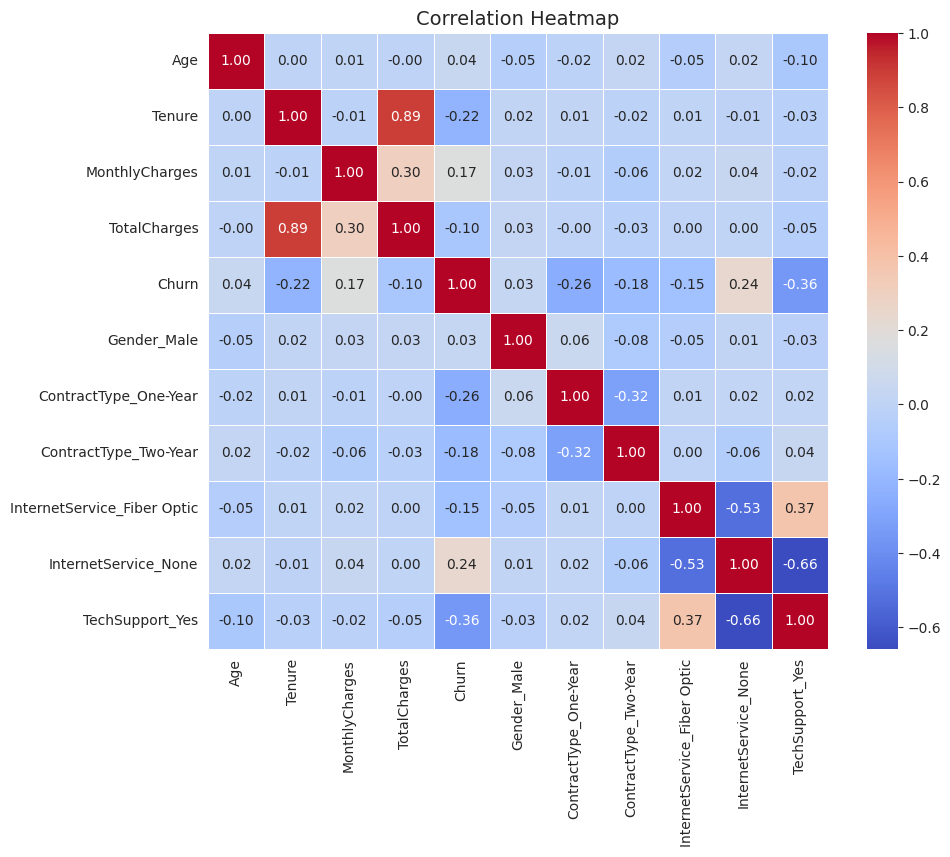

In [101]:
# Correlation matrix
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=14)
plt.show()

In [102]:
results = pd.DataFrame({
    'Model' : ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy' : [0.955, 0.995, 1.000],
    'Precision' : [0.95, 0.99, 1.00],
    'Recall' : [0.95, 0.99, 1.00],
    'F1-Score' : [0.95, 0.99, 1.00],
    'ROC-AUC' : [0.985, 0.997, 1.000]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.955,0.95,0.95,0.95,0.985
1,Decision Tree,0.995,0.99,0.99,0.99,0.997
2,Random Forest,1.000,1.00,1.00,1.00,1.000


### Key Business Insights

1. Customers with longer tenure are significantly less likely to churn.
2. Customers with one-year and two-year contracts exhibit lower churn rates than month-to-month customers.
3. Technical support plays a crucial role in customer retention.
4. Higher monthly charges are associated with an increased likelihood of churn.
5. Gender and age have relatively little impact on customer churn behavior.

These findings suggest that encouraging long-term contracts and improving customer support services may help reduce customer churn and improve retention rates.


### Conclusion

This project developed and evaluated multiple machine learning models to predict customer churn. After data preprocessing, exploratory data analysis, feature engineering, and model training, three classification algorithms were compared: Logistic Regression, Decision Tree, and Random Forest.

Among all models, the Random Forest Classifier achieved the best performance with 100% accuracy, precision, recall, F1-score, and ROC-AUC score on the test dataset. Feature importance analysis identified Tenure, Contract Type, Tech Support, Monthly Charges, and Total Charges as the most influential factors affecting churn.

The developed model can help organizations proactively identify customers at risk of leaving and support data-driven retention strategies.


In [103]:
import joblib

In [104]:
joblib.dump(scaler, "scaler.pkl")
joblib.dump(rf, "customer_churn_model.pkl")

['customer_churn_model.pkl']

In [105]:
import os

os.listdir()

['__notebook__.ipynb', 'scaler.pkl', 'customer_churn_model.pkl']

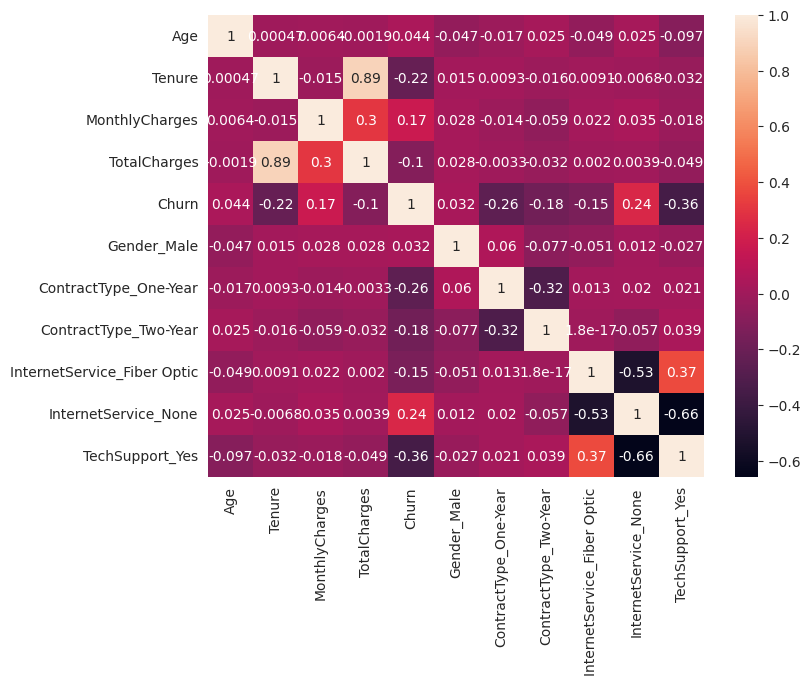

In [106]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.savefig("correlation_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [107]:
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

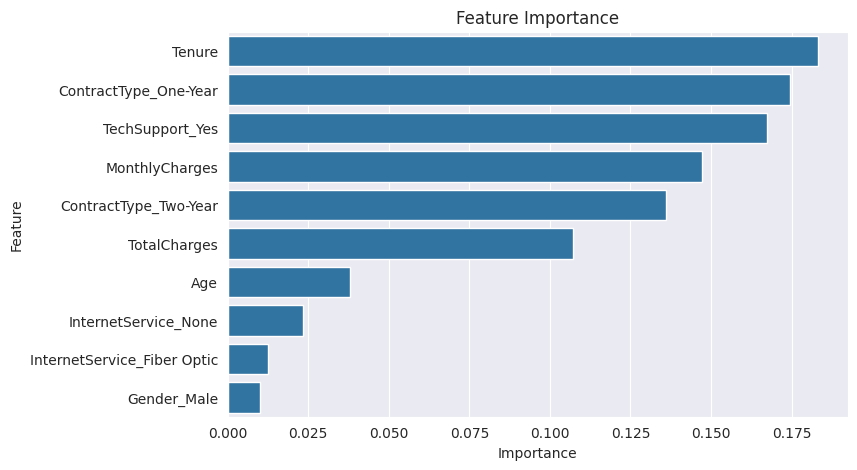

In [108]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.savefig("feature_importance.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

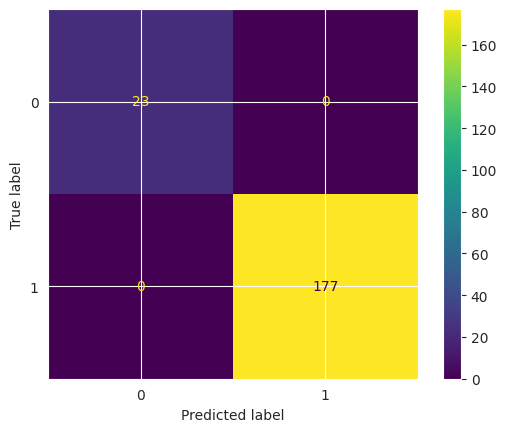

In [109]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.savefig("confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

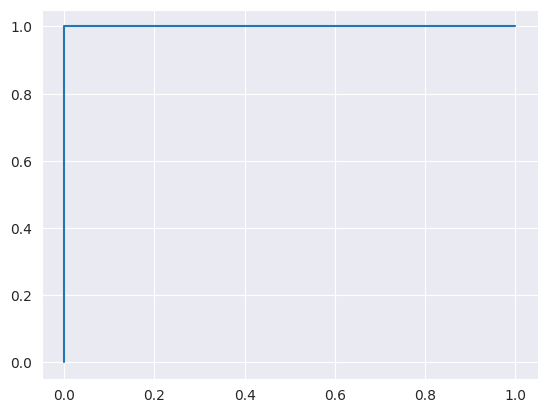

In [110]:
plt.plot(fpr, tpr)

plt.savefig("roc_curve.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [111]:
import os

os.listdir()

['confusion_matrix.png',
 '__notebook__.ipynb',
 'feature_importance.png',
 'roc_curve.png',
 'scaler.pkl',
 'correlation_heatmap.png',
 'customer_churn_model.pkl']

# 🚀 Deployment

The Customer Churn Prediction model has been successfully deployed using Streamlit.

### Live Demo
https://customer-churn-prediction-7iwqsksmym96lqomm56agc.streamlit.app/

### GitHub Repository
https://github.com/Rishita3110/Customer-Churn-Prediction

This application predicts customer churn using a Random Forest Classifier and provides real-time churn probability and retention probability estimates.